# Missing Data Analysis

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import seaborn as sns
import sys

## Loading the datasets

In [12]:
BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

PROCESSED_DIR = BASE_DIR / "data"/ "processed"
COMPANIES_DIR = BASE_DIR / "data" / "raw" / "companies"

feature_matrix_path = os.path.join(PROCESSED_DIR, "feature_matrix_first.parquet")
prices_matrix_path = os.path.join(COMPANIES_DIR, "prices.parquet")

feature_matrix_df = pd.read_parquet(feature_matrix_path)
prices_df = pd.read_parquet(prices_matrix_path)

In [5]:
feature_matrix_df.head()

,Date,Ticker,market_beta_63,industry_beta_63,market_resid_vol_126,industry_resid_vol_126,mean_volatility_10,mean_volatility_21,mean_volatility_63,amihud_21,momentum_252_21,momentum_liquidity_21,reversal_5,rsr_21,future_return_5d
0,2022-06-14,360.AX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.035714
1,2022-06-14,4DX.AX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.177778
2,2022-06-14,A2M.AX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023866
3,2022-06-14,AAI.AX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-06-14,AGL.AX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.036471


In [14]:
prices_df.head()

,Date,360.AX,4DX.AX,A2M.AX,AAI.AX,AGL.AX,AIA.AX,AII.AX,ALD.AX,ALK.AX,...,WGX.AX,WHC.AX,WOR.AX,WOW.AX,WTC.AX,XRO.AX,XYZ.AX,YAL.AX,ZIM.AX,ZIP.AX
0,2022-06-14,2.80,0.450,4.081915,NaN,7.081392,6.280376,1.484999,27.822613,0.865,...,1.189692,4.117449,12.679449,29.852810,36.297779,81.900002,93.139999,3.555563,20.861212,0.530
1,2022-06-15,2.62,0.400,3.965011,NaN,7.148040,6.289921,1.484999,26.877420,0.870,...,1.189692,4.101397,12.356130,29.385115,34.960396,77.610001,86.550003,3.536169,20.333294,0.500
2,2022-06-16,2.62,0.385,3.906559,NaN,6.881447,6.127661,1.559999,26.659302,0.895,...,1.214272,4.277973,12.321176,29.102739,35.574604,77.849998,87.839996,3.542634,21.695660,0.505
3,2022-06-17,2.51,0.400,4.072173,NaN,7.006413,6.156296,1.529999,26.247293,0.935,...,1.302762,4.013108,12.085238,29.173330,35.485443,73.519997,81.000000,3.400411,21.286951,0.540
4,2022-06-20,2.60,0.350,4.130625,NaN,6.931433,6.251742,1.529999,25.859520,0.855,...,1.283097,3.643902,11.700747,29.014492,35.752918,75.720001,84.330002,3.251724,20.988934,0.530


## Exploratory Data Analysis

### An analysis of raw price data

There are 15 missing companies: ['RYM.AX', 'L1G.AX', 'DPM.AX', 'GGP.AX', 'VGN.AX', 'SX2.AX', 'AAI.AX', 'GYG.AX', 'CSC.AX', 'NEM.AX', 'FRW.AX', 'ASK.AX', 'LNW.AX', 'IFL.AX', 'NSR.AX']


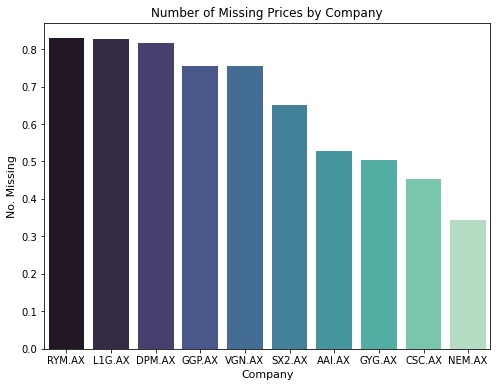

In [108]:
ticker_missing_df = prices_df.isna().mean()

ticker_missing_df = ticker_missing_df.loc[ticker_missing_df > 0].sort_values(ascending=False).reset_index().rename(columns={
    "index": "Company", 
    0: "No. Missing"
})

missing_companies = list(ticker_missing_df["Company"])

print(f"There are {ticker_missing_df.shape[0]} missing companies: {missing_companies}")

plt.figure(figsize=(8, 6))
sns.barplot(data=ticker_missing_df[:10], x="Company", y="No. Missing", palette="mako")
plt.title("Number of Missing Prices by Company", fontsize=12)
plt.xlabel("Company", fontsize=11)
plt.ylabel("No. Missing", fontsize=11)
plt.show()

In [109]:
listing_summary = []    
for company in missing_companies:
    s = prices_df[["Date", company]].dropna()
    listing_summary.append({
        "Company": company, 
        "Start Date": s["Date"].min(),
        "End Date": s["Date"].max()
    })
listing_df = pd.DataFrame(listing_summary)
listing_df

,Company,Start Date,End Date
0,RYM.AX,2025-10-06,2026-06-12
1,L1G.AX,2025-10-03,2026-06-12
2,DPM.AX,2025-09-18,2026-06-12
3,GGP.AX,2025-06-24,2026-06-12
4,VGN.AX,2025-06-24,2026-06-12
5,SX2.AX,2025-01-17,2026-06-12
6,AAI.AX,2024-07-24,2026-06-12
7,GYG.AX,2024-06-20,2026-06-12
8,CSC.AX,2024-04-08,2026-06-12
9,NEM.AX,2023-10-27,2026-06-12


Missing price observations are primarily explained by IPOs and delistings rather than data quality issues. Several stocks only begin trading during 2024–2025, resulting in substantial missing history prior to their listing dates, while delisted stocks exhibit missing observations near the end of the sample. As a result, long-lookback features such as 12–1 momentum and 126-day residual volatility inherit missing values because insufficient price history is available for their calculation. Therefore, the missingness is structural and expected, making row removal more appropriate than imputing artificial values.

### Feature Level Missingness

In [19]:
feature_missing_df = pd.DataFrame({ 
    "missing_count": feature_matrix_df.isna().sum(),
    "missing_pct": feature_matrix_df.isna().mean() * 100
})

feature_missing_df.sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
momentum_liquidity_21,62859,31.056818
momentum_252_21,61667,30.467885
market_resid_vol_126,57377,28.348320
industry_resid_vol_126,57377,28.348320
mean_volatility_63,20199,9.979743
market_beta_63,20006,9.884387
industry_beta_63,20006,9.884387
mean_volatility_21,11982,5.919960
rsr_21,11606,5.734190
amihud_21,11271,5.568676


Feature-level missingness is concentrated among a small number of long-horizon signals, with momentum_liquidity_21 (31.1%), momentum_252_21 (30.5%), and the residual volatility features (28.3%) exhibiting the highest rates of missing observations. In contrast, shorter-horizon features such as reversal_5, mean_volatility_10, amihud_21, and rsr_21 have substantially lower missingness, generally below 6%. Combined with the earlier analysis of IPOs and delistings, this suggests that missingness is primarily driven by limited historical price availability and the long lookback windows required to construct certain signals rather than data quality issues. To assess the practical impact of this missingness on model training, we next examine complete-case coverage to determine how many observations remain after requiring all features to be available.

**Complete Case Coverage**

In [125]:
row_missing = feature_matrix_df.isna().sum(axis=1)
row_missing = row_missing.value_counts().reset_index()
row_missing = row_missing.rename(columns={
    "index": "Missing Features", 
    "count": "Count"
})
row_missing

,Missing Features,Count
0,0,138564
1,4,37020
2,7,8335
3,13,7406
4,2,4898
5,9,2170
6,11,1005
7,12,1000
8,1,977
9,5,498


In [126]:
complete_case_pct = (
    row_missing.loc[
        row_missing["Missing Features"] == 0,
        "Count"
    ].iloc[0]
    / row_missing["Count"].sum()
) * 100

print(f"{complete_case_pct:.2f}%")

68.46%


Complete-case coverage is 68.46%, meaning most observations contain all required features for model training. Among incomplete rows, missingness occurs in distinct clusters, particularly rows with 4, 7, or 13 missing features. This supports the earlier finding that missingness is structural and block-like, driven by IPOs, delistings, and shared lookback requirements rather than isolated random gaps.

**Missing Correlation**

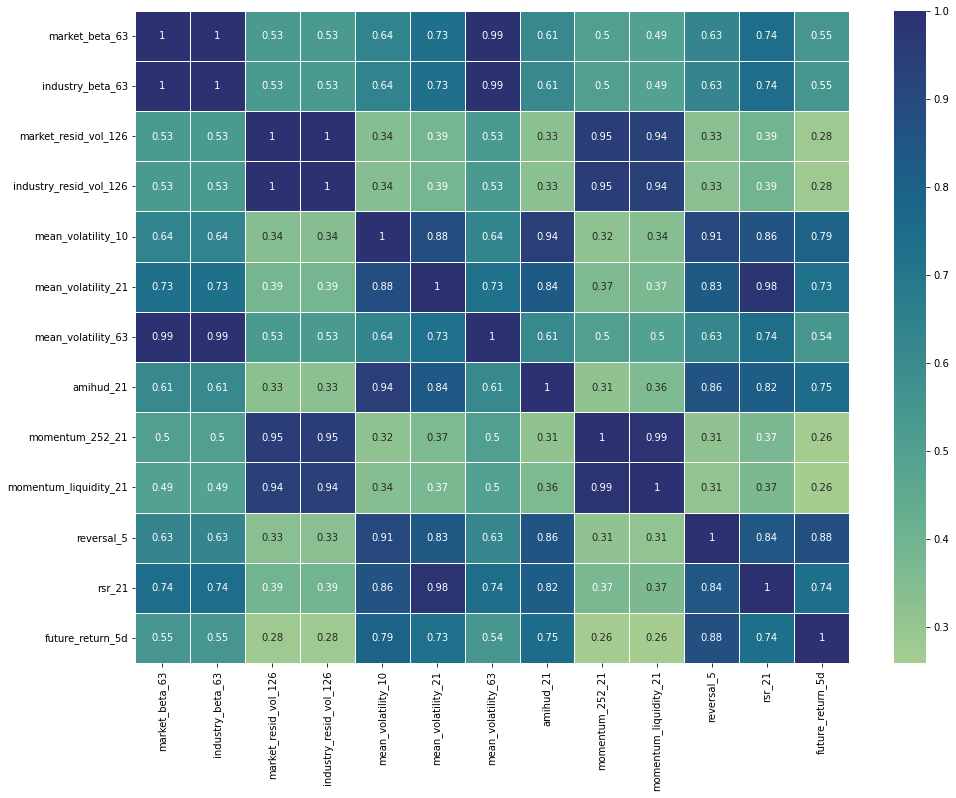

In [137]:
missing_df = feature_matrix_df[feature_matrix_df.columns[2:]].isna().astype(int)
missing_corr = missing_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(missing_corr, cmap="crest", annot=True, linewidths=1)
plt.show()

Missingness is highly correlated within related feature groups, indicating that missing observations arise in systematic blocks rather than independently across variables. Beta features, residual volatility features, and momentum-based features tend to be missing together, consistent with shared price inputs and rolling-window construction. This supports the conclusion that missingness is structural and driven by IPOs, delistings, and insufficient historical lookback periods.

missing_df = feature_matrix.isna().astype(int)

missing_corr = missing_df.corr()

### Date Level Missingness

In [ ]:
feature_list = feature_matrix_df.columns[2:-1]
target_feature = feature_matrix_df.columns[-1]

future_return_5d


**By feature (excl. target)**

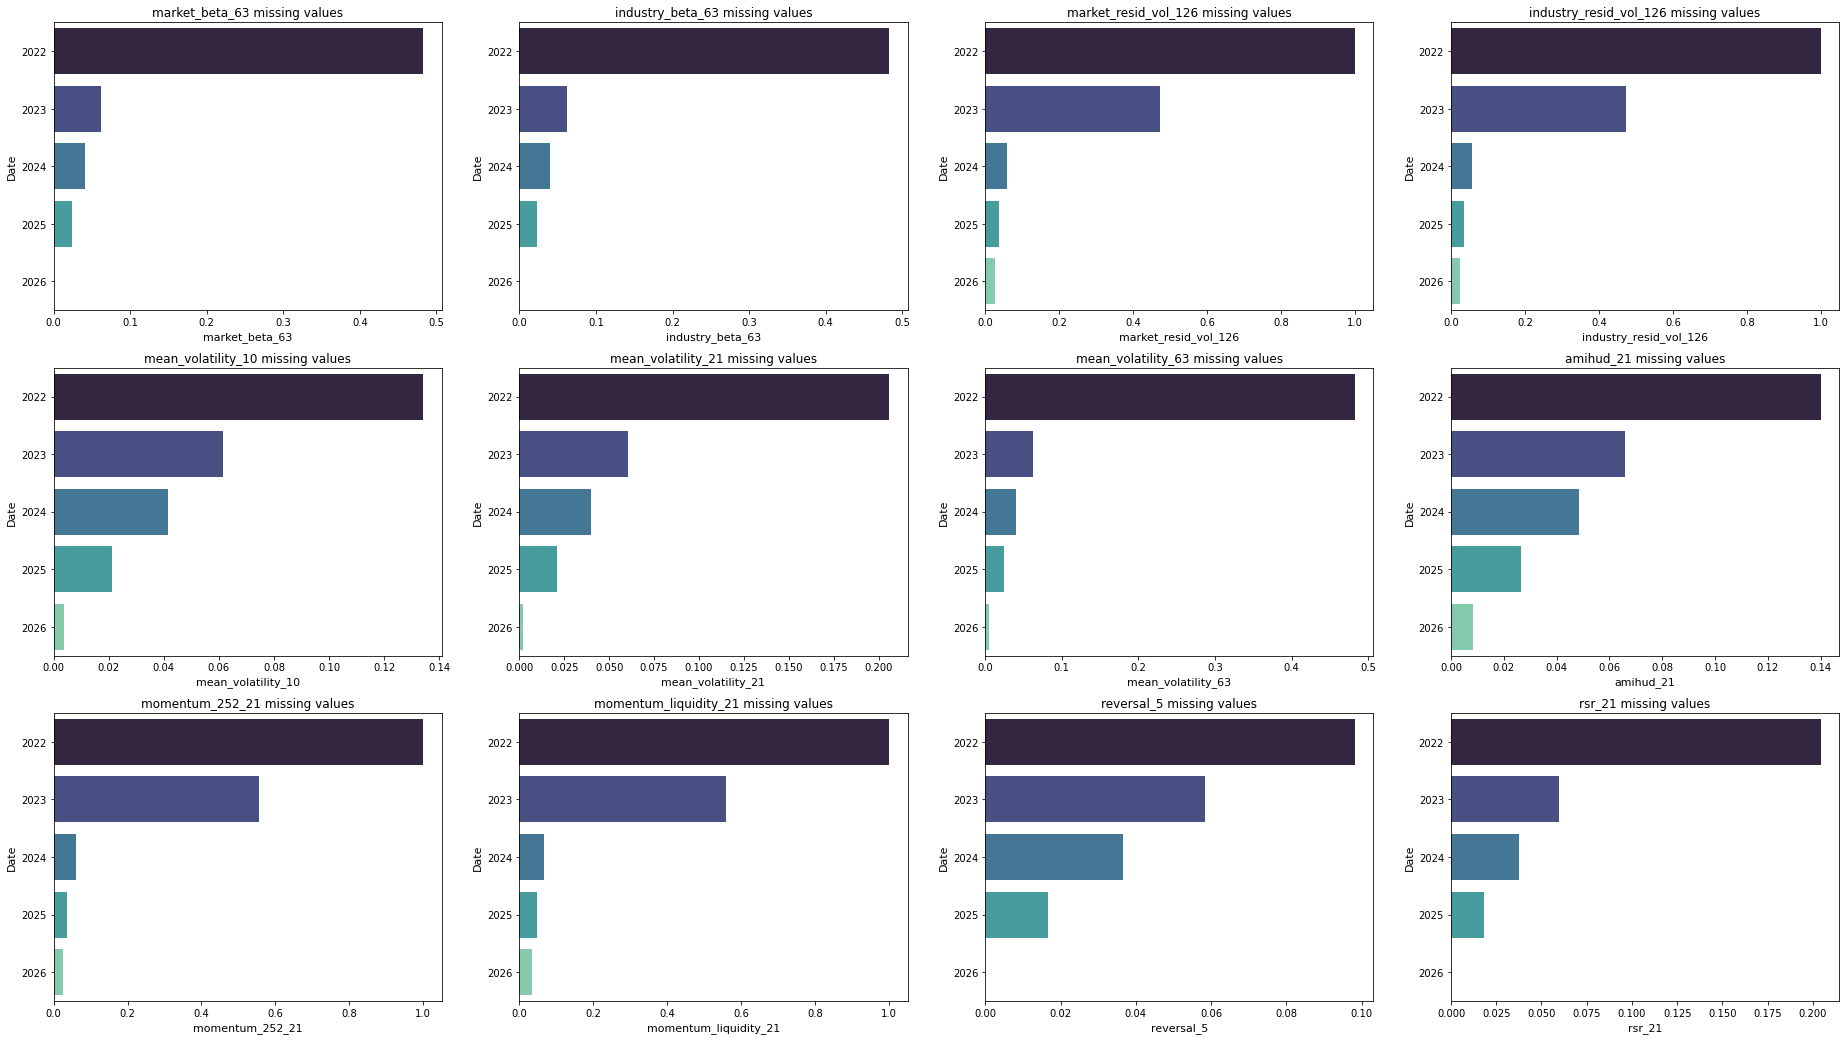

In [91]:
fig, axs = plt.subplots(3, 4, figsize=(32, 18))

axs = axs.ravel()
for i, feature in enumerate(feature_list): 
    axs[i].set_title(f"{feature} missing values", fontsize=12)
    axs[i].set_xlabel(f"{feature}", fontsize=11)
    axs[i].set_ylabel(f"Year", fontsize=11)
    
    missing_by_year = (
        feature_matrix_df
        .groupby(feature_matrix_df["Date"].dt.year)[feature]
        .apply(lambda x: x.isna().mean())
    ).reset_index()
    
    sns.barplot(
        data=missing_by_year, x=feature, y="Date", ax=axs[i], orient="h", palette="mako"
    )
    
    i += 1
    
plt.show()

Feature-level missingness is concentrated on a small number of dates, with the highest levels occurring on a handful of observations. The pattern is most pronounced for features requiring long lookback windows, such as momentum and residual volatility measures. This suggests that insufficient historical data at the beginning of the sample is a major driver of missingness, with the effect amplified by IPOs and limited trading histories. Consequently, the missingness appears structural and arises from feature construction requirements rather than data quality issues.

**By target**

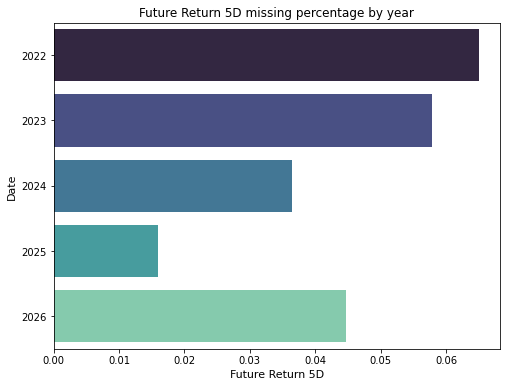

In [99]:
missing_by_year = (
    feature_matrix_df
    .groupby(feature_matrix_df["Date"].dt.year)[target_feature]
    .apply(lambda x: x.isna().mean())
).reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(
    data=missing_by_year, x=target_feature, y="Date", orient="h", palette="mako"
)
plt.xlabel("Future Return 5D", fontsize=11)
plt.ylabel("Date", fontsize=11)
plt.title("Future Return 5D missing percentage by year")
plt.show()